**SuperStore Sales Analytics Project**

In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
### Load Dataset
df = pd.read_csv("SuperStore_Orders.csv.bz2", encoding='latin1')
print(df.head())
print("Shape of Dataset:")
print(df.shape)
print("\nColumn Names:")
print(df.columns)
print("\nDataset Information:")
print(df.info())

          order_id  order_date   ship_date       ship_mode    customer_name  \
0     AG-2011-2040  01-01-2011  06-01-2011  Standard Class  Toby Braunhardt   
1    IN-2011-47883  01-01-2011  08-01-2011  Standard Class      Joseph Holt   
2     HU-2011-1220  01-01-2011  05-01-2011    Second Class    Annie Thurman   
3  IT-2011-3647632  01-01-2011  05-01-2011    Second Class     Eugene Moren   
4    IN-2011-47883  01-01-2011  08-01-2011  Standard Class      Joseph Holt   

       segment            state    country  market   region  ...  \
0     Consumer      Constantine    Algeria  Africa   Africa  ...   
1     Consumer  New South Wales  Australia    APAC  Oceania  ...   
2     Consumer         Budapest    Hungary    EMEA     EMEA  ...   
3  Home Office        Stockholm     Sweden      EU    North  ...   
4     Consumer  New South Wales  Australia    APAC  Oceania  ...   

          category sub_category                 product_name sales quantity  \
0  Office Supplies      Storage      

**DATA CLEANING**

In [ ]:
#  Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Check Duplicate Rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

#  Remove Duplicate Rows
df = df.drop_duplicates()
print("\nShape After Removing Duplicates:")
print(df.shape)

#  Convert Date Columns
df['order_date'] = pd.to_datetime(df['order_date'], format='%d-%m-%Y')
df['ship_date'] = pd.to_datetime(df['ship_date'], format='%d-%m-%Y')

print("\nDate Columns Converted Successfully")

#  Check Data Types
print("\nData Types:")
print(df.dtypes)

#  Final Cleaned Dataset Preview
print("\nCleaned Dataset Preview:")
print(df.head())

#  Save Cleaned Dataset
df.to_csv("Cleaned_SuperStore_Data.csv", index=False)
print("\nCleaned Dataset Saved Successfully")


Missing Values:
order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

Duplicate Rows:
0

Shape After Removing Duplicates:
(51290, 21)

Date Columns Converted Successfully

Data Types:
order_id                  object
order_date        datetime64[ns]
ship_date         datetime64[ns]
ship_mode                 object
customer_name             object
segment                   object
state                     object
country                   object
market                    object
region                    object
product_id                object
category                  object
sub_category              object
produc

In [ ]:
# Convert sales column to numeric datatype

df['sales'] = pd.to_numeric(df['sales'], errors='coerce')
print(df['sales'].dtype)
print(df.dtypes)

float64
order_id                  object
order_date        datetime64[ns]
ship_date         datetime64[ns]
ship_mode                 object
customer_name             object
segment                   object
state                     object
country                   object
market                    object
region                    object
product_id                object
category                  object
sub_category              object
product_name              object
sales                    float64
quantity                   int64
discount                 float64
profit                   float64
shipping_cost            float64
order_priority            object
year                       int64
dtype: object


**EXPLORATORY DATA ANALYSIS** (EDA)

In [ ]:
#Basic Business Analysis
print("Total Sales:", df['sales'].sum())

print("Total Profit:", df['profit'].sum())

print("Average Sales:", df['sales'].mean())

print("Average Profit:", df['profit'].mean())



Total Sales: 7835128.0
Total Profit: 1469034.8212799998
Average Sales: 161.01783806000822
Average Profit: 28.64173954533047


category
Furniture          2406605.0
Office Supplies    2790258.0
Technology         2638265.0
Name: sales, dtype: float64


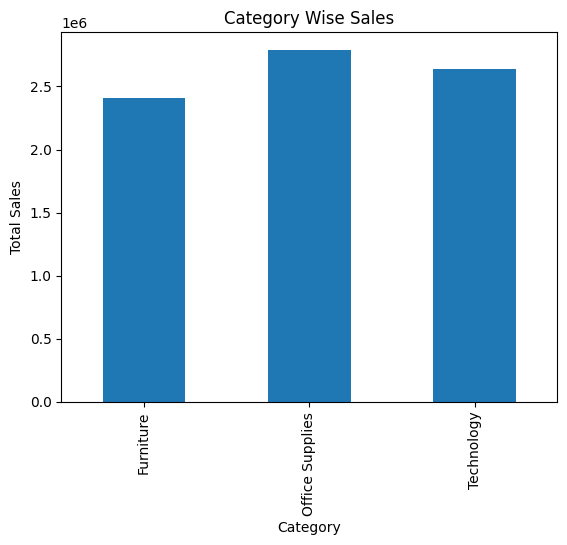

In [ ]:
#Category-wise Sales Analysis
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')
category_sales = df.groupby('category')['sales'].sum()
print(category_sales)

#visualization
import matplotlib.pyplot as plt
category_sales.plot(kind='bar')
plt.title("Category Wise Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

category
Furniture          286782.25380
Office Supplies    518473.83430
Technology         663778.73318
Name: profit, dtype: float64


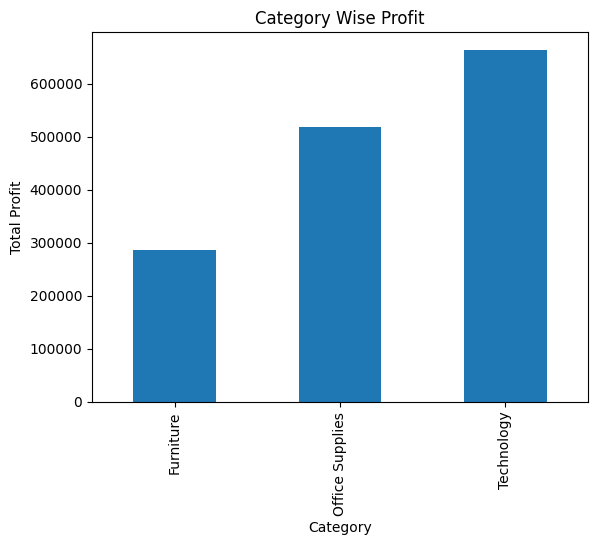

In [ ]:
# CATEGORY WISE PROFIT
category_profit = df.groupby('category')['profit'].sum()
print(category_profit)

#visualization
import matplotlib.pyplot as plt
category_profit.plot(kind='bar')
plt.title("Category Wise Profit")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.show()

region
Africa             538115.0
Canada              50314.0
Caribbean          251441.0
Central           1806638.0
Central Asia       389506.0
EMEA               575562.0
East               366492.0
North              790546.0
North Asia         453686.0
Oceania            625382.0
South             1031101.0
Southeast Asia     532172.0
West               424173.0
Name: sales, dtype: float64


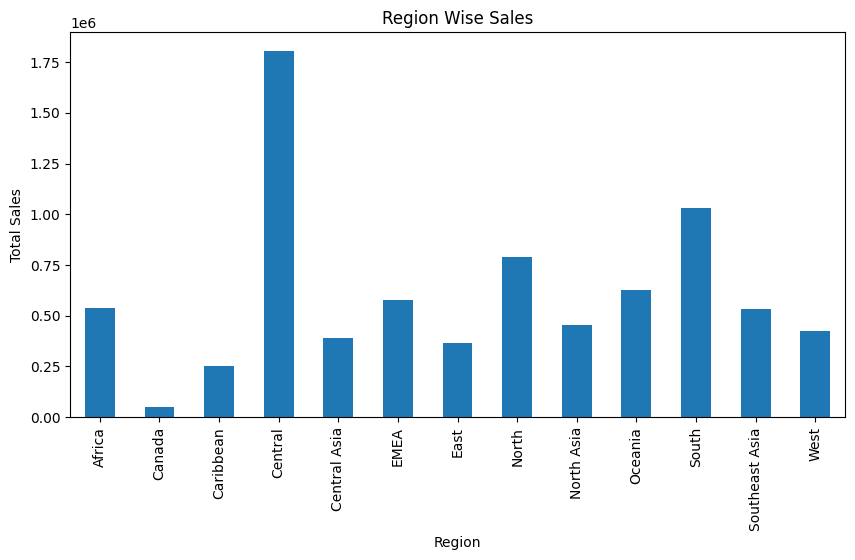

In [ ]:
# REGION WISE SALES
region_sales = df.groupby('region')['sales'].sum()
print(region_sales)

#visualization
import matplotlib.pyplot as plt
region_sales.plot(kind='bar', figsize=(10,5))
plt.title("Region Wise Sales")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

sub_category
Chairs         927982.0
Storage        913499.0
Phones         870518.0
Bookcases      811505.0
Copiers        782710.0
Accessories    570054.0
Machines       414983.0
Appliances     377590.0
Furnishings    377432.0
Art            371050.0
Binders        346130.0
Tables         289686.0
Paper          244307.0
Supplies       210069.0
Envelopes      170926.0
Fasteners       83254.0
Labels          73433.0
Name: sales, dtype: float64


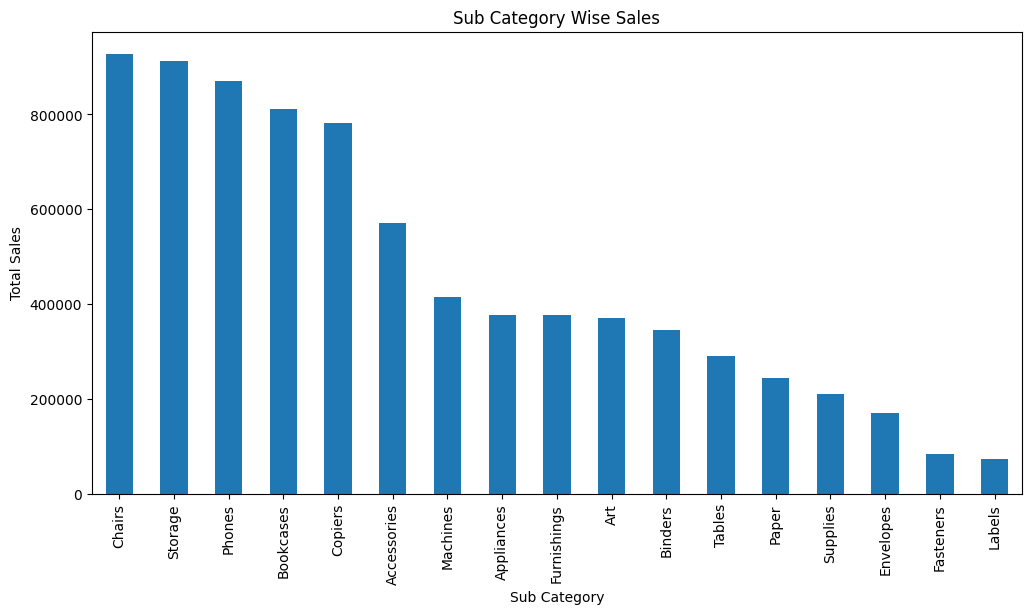

In [ ]:
# SUB CATEGORY SALES ANALYSIS
sub_category_sales = df.groupby('sub_category')['sales'].sum().sort_values(ascending=False)
print(sub_category_sales)

#visualization
import matplotlib.pyplot as plt
sub_category_sales.plot(kind='bar', figsize=(12,6))
plt.title("Sub Category Wise Sales")
plt.xlabel("Sub Category")
plt.ylabel("Total Sales")
plt.show()

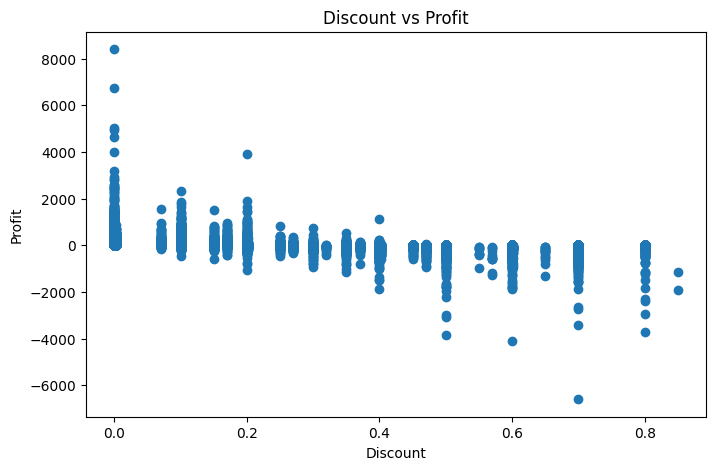

In [ ]:
# DISCOUNT VS PROFIT
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.scatter(df['discount'], df['profit'])
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

In [ ]:
# Correlation between discount and profit
correlation = df['discount'].corr(df['profit'])

print("Correlation:", correlation)

Correlation: -0.3163749562484039


In [ ]:
# YEAR WISE SALES
year_sales = df.groupby('year')['sales'].sum()
print(year_sales)

year
2011    1378151.0
2012    1681499.0
2013    2107021.0
2014    2668457.0
Name: sales, dtype: float64


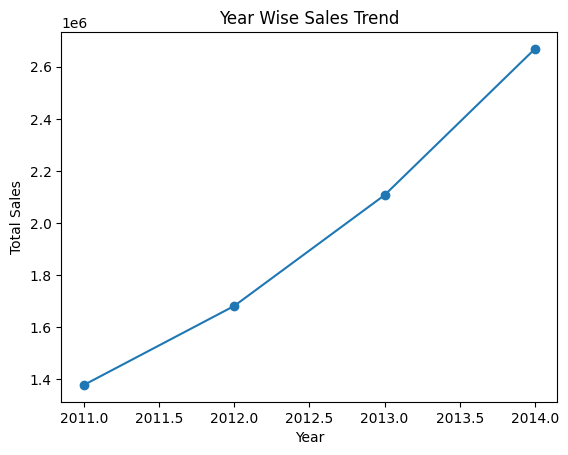

In [ ]:
#Sales Trend Visualization
import matplotlib.pyplot as plt
year_sales.plot(kind='line', marker='o')
plt.title("Year Wise Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.show()

product_name
Eldon File Cart, Single Width                         31319.0
Rogers File Cart, Single Width                        22645.0
Tenex File Cart, Single Width                         20778.0
Smead File Cart, Single Width                         20775.0
Office Star Executive Leather Armchair, Adjustable    19355.0
Fellowes Lockers, Industrial                          19172.0
Smead Lockers, Industrial                             18648.0
Hewlett Copy Machine, Color                           16849.0
Rogers Lockers, Blue                                  16494.0
Fellowes Lockers, Wire Frame                          16470.0
Name: sales, dtype: float64


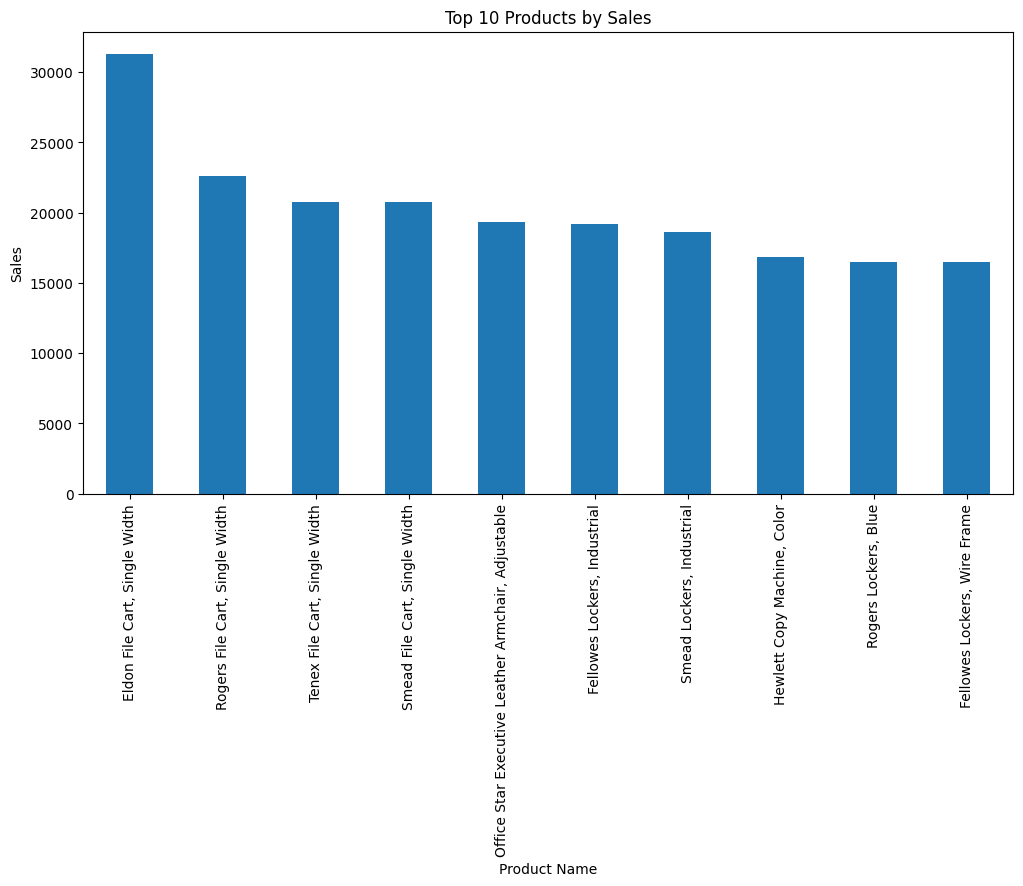

In [ ]:
# TOP 10 PRODUCTS
top_products = df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)
print(top_products)

#visualization
import matplotlib.pyplot as plt
top_products.plot(kind='bar', figsize=(12,6))
plt.title("Top 10 Products by Sales")
plt.xlabel("Product Name")
plt.ylabel("Sales")
plt.show()

customer_name
Eric Murdock        19489.0
John Grady          19483.0
Maria Etezadi       18237.0
Theone Pippenger    17416.0
Dan Reichenbach     16705.0
Ben Ferrer          16661.0
Randy Bradley       16399.0
Mathew Reese        16125.0
Muhammed Yedwab     16091.0
Steven Ward         15984.0
Name: sales, dtype: float64


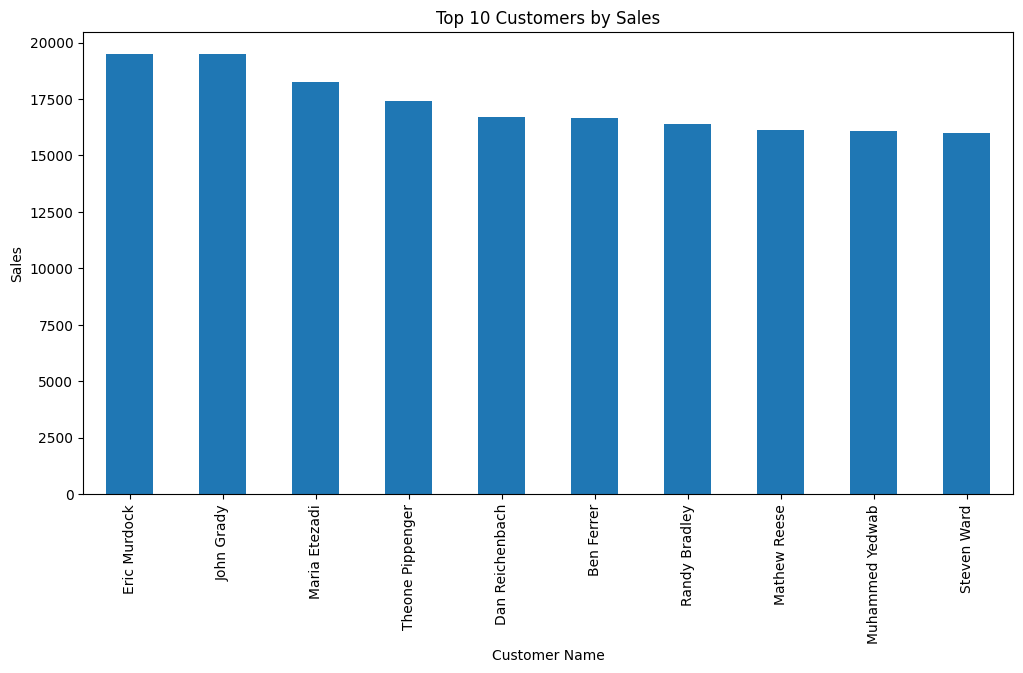

In [ ]:
#TOP CUSTOMERS ANALYSIS
top_customers = df.groupby('customer_name')['sales'].sum().sort_values(ascending=False).head(10)
print(top_customers)

#visualization
import matplotlib.pyplot as plt
top_customers.plot(kind='bar', figsize=(12,6))
plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer Name")
plt.ylabel("Sales")
plt.show()

ship_mode
First Class       1133651.0
Same Day           398788.0
Second Class      1583086.0
Standard Class    4719603.0
Name: sales, dtype: float64


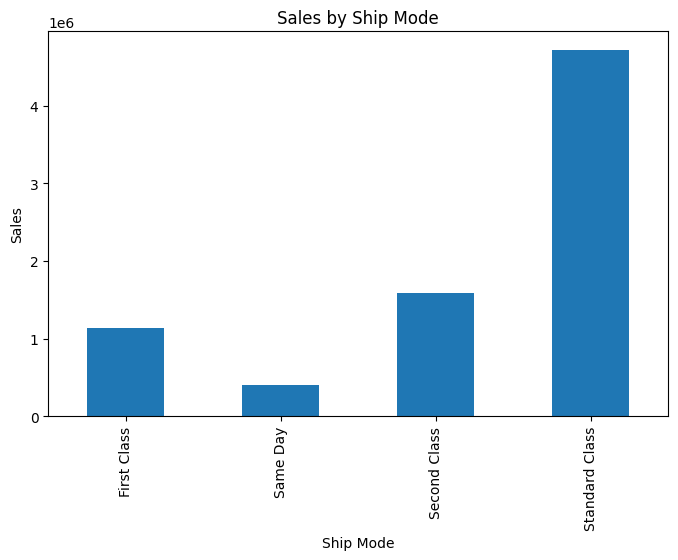

In [ ]:
#SALES BY SHIPPING MODE
ship_sales = df.groupby('ship_mode')['sales'].sum()
print(ship_sales)

#visualization
ship_sales.plot(kind='bar', figsize=(8,5))
plt.title("Sales by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Sales")
plt.show()



In [ ]:
#PROFITABILITY BY CATEGORY
category_profit_margin = df.groupby('category')[['sales','profit']].sum()
category_profit_margin['profit_margin_%'] = (category_profit_margin['profit'] / category_profit_margin['sales']) * 100
print(category_profit_margin)

#visualization
loss_orders = df[df['profit'] < 0]
print("Total Loss Orders:", len(loss_orders))
print(loss_orders[['product_name','sales','profit']].head(10))

                     sales        profit  profit_margin_%
category                                                 
Furniture        2406605.0  286782.25380        11.916465
Office Supplies  2790258.0  518473.83430        18.581573
Technology       2638265.0  663778.73318        25.159669
Total Loss Orders: 12543
                                 product_name  sales    profit
3                 Enermax Note Cards, Premium   45.0  -26.0550
8                 Hewlett Wireless Fax, Laser  912.0 -319.4640
10                  Tenex Lockers, Industrial  338.0 -122.8005
11  Chromcraft Round Table, Adjustable Height  211.0  -70.3995
14              Hon Rocking Chair, Set of Two  159.0  -95.6760
18                      SAFCO Chairmat, Black   69.0  -26.4120
19                      Smead File Cart, Blue  135.0  -45.9018
33      Jiffy Interoffice Envelope, Set of 50   74.0 -107.8560
37                 Boston Markers, Easy-Erase   27.0  -21.9000
40                Eldon Folders, Single Width   17.0   

Total Loss Orders: 12543
                                 product_name  sales    profit
3                 Enermax Note Cards, Premium   45.0  -26.0550
8                 Hewlett Wireless Fax, Laser  912.0 -319.4640
10                  Tenex Lockers, Industrial  338.0 -122.8005
11  Chromcraft Round Table, Adjustable Height  211.0  -70.3995
14              Hon Rocking Chair, Set of Two  159.0  -95.6760
18                      SAFCO Chairmat, Black   69.0  -26.4120
19                      Smead File Cart, Blue  135.0  -45.9018
33      Jiffy Interoffice Envelope, Set of 50   74.0 -107.8560
37                 Boston Markers, Easy-Erase   27.0  -21.9000
40                Eldon Folders, Single Width   17.0   -1.0500


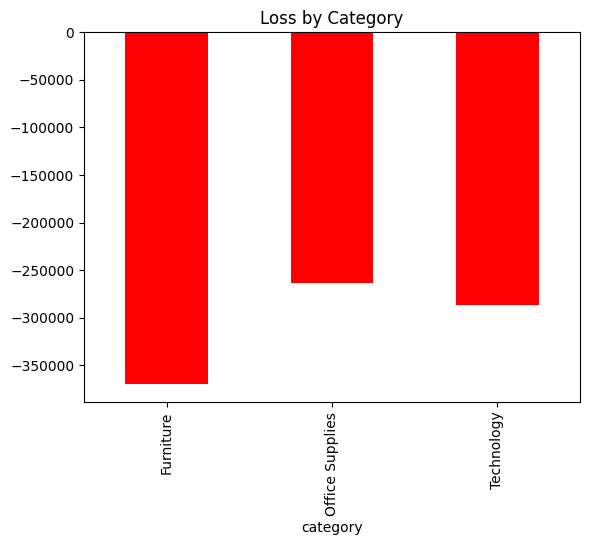

In [ ]:
#LOSS ANALYSIS
loss_orders = df[df['profit'] < 0]
print("Total Loss Orders:", len(loss_orders))
print(loss_orders[['product_name','sales','profit']].head(10))

#visualization
loss_by_category = loss_orders.groupby('category')['profit'].sum()
loss_by_category.plot(kind='bar', color='red')
plt.title("Loss by Category")
plt.show()




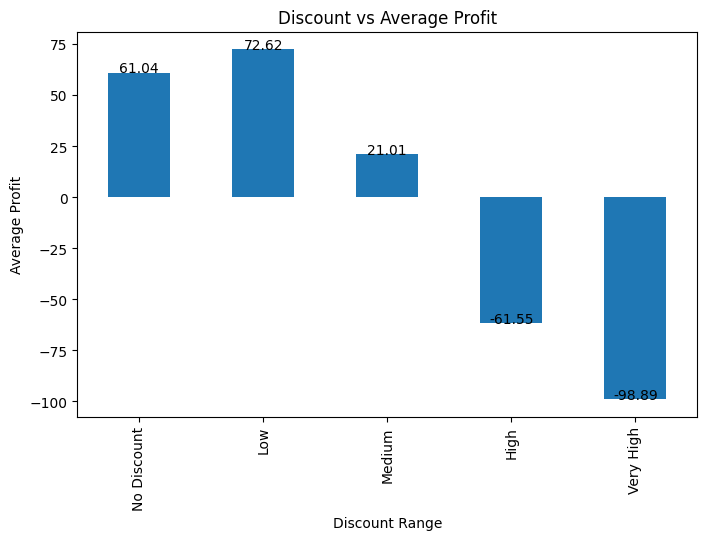


Average Profit by Discount Range:
discount_range
No Discount    61.039514
Low            72.615258
Medium         21.005280
High          -61.551917
Very High     -98.893015
Name: profit, dtype: float64


In [ ]:
#HIGH DISCOUNT IMPACT ANALYSIS
# Discount range creation
df['discount_range'] = pd.cut(
    df['discount'],
    bins=[-0.01, 0, 0.1, 0.3, 0.5, 1],
    labels=['No Discount', 'Low', 'Medium', 'High', 'Very High']
)

# Average profit calculation
discount_profit = df.groupby(
    'discount_range',
    observed=False
)['profit'].mean()

# Plot
ax = discount_profit.plot(kind='bar', figsize=(8,5))

plt.title("Discount vs Average Profit")
plt.xlabel("Discount Range")
plt.ylabel("Average Profit")

# Value labels on bars
for i, value in enumerate(discount_profit):
    plt.text(i, value, round(value, 2), ha='center')

plt.show()

# Detailed values print
print("\nAverage Profit by Discount Range:")
print(discount_profit)

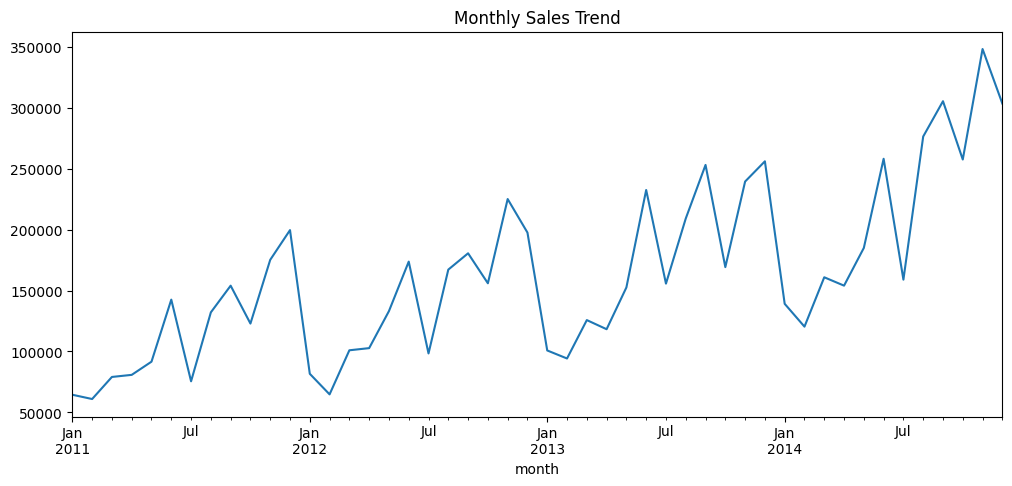

In [ ]:
#Monthly Trend
df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.to_period('M')
monthly_sales = df.groupby('month')['sales'].sum()
monthly_sales.plot(figsize=(12,5))
plt.title("Monthly Sales Trend")
plt.show()


Final Clean Export


In [ ]:
# Final dataset save
df.to_csv("superstore_cleaned_final.csv", index=False)
print("Final Cleaned Dataset Saved Successfully")

Final Cleaned Dataset Saved Successfully


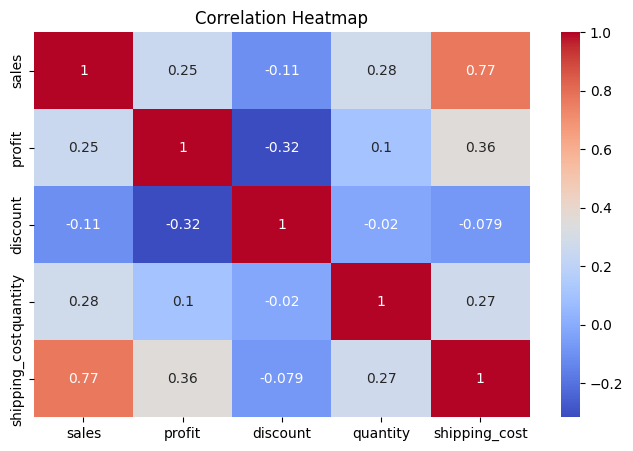

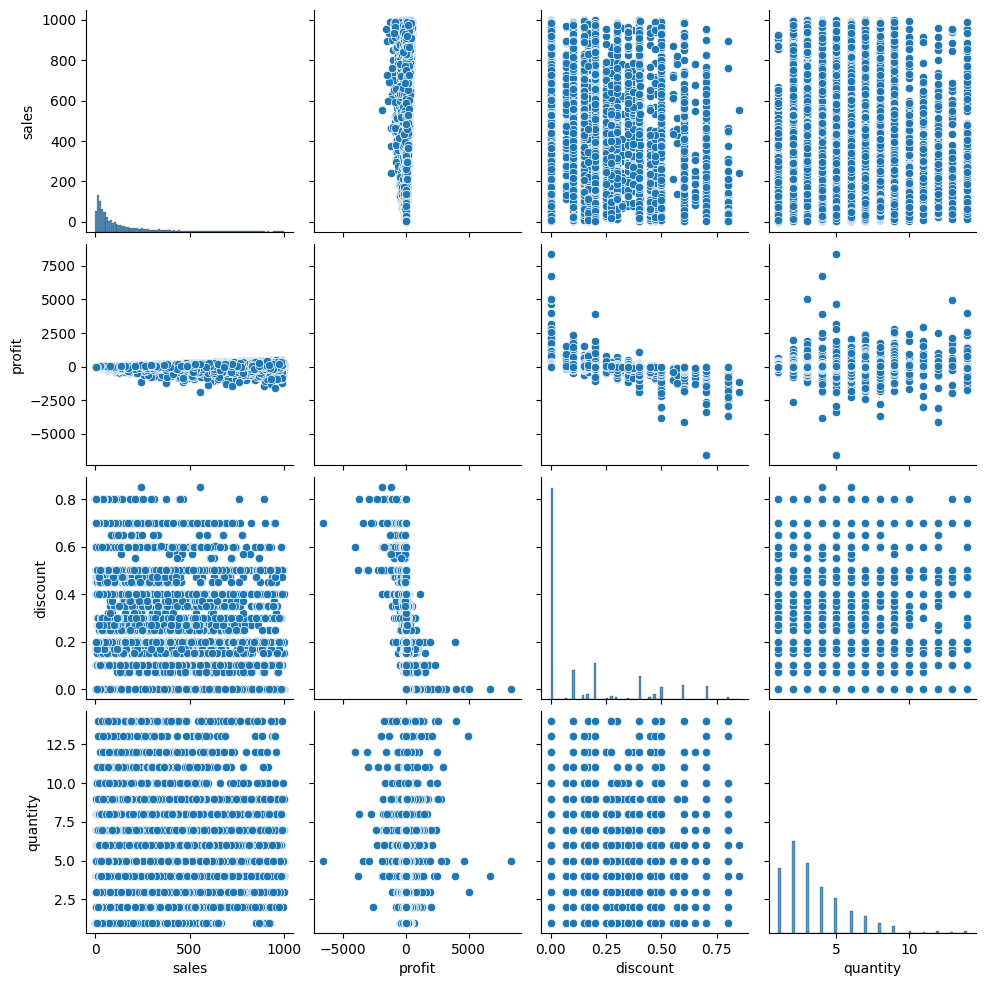

In [ ]:

# Numerical columns correlation
corr = df[['sales', 'profit', 'discount', 'quantity', 'shipping_cost']].corr()

# Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#Pairplot
sns.pairplot(df[['sales', 'profit', 'discount', 'quantity']])
plt.show()



Business Insights**

In [ ]:
print("KEY INSIGHTS")
print("----------------------")

print("1. Sales increased significantly from 2011 to 2014.")

print("2. Technology category generated the highest profit.")

print("3. Higher discounts reduced overall profit.")

print("4. Some products contributed heavily to total sales.")

print("5. Certain regions performed better than others.")

print("6. High discount orders often resulted in losses.")

KEY INSIGHTS
----------------------
1. Sales increased significantly from 2011 to 2014.
2. Technology category generated the highest profit.
3. Higher discounts reduced overall profit.
4. Some products contributed heavily to total sales.
5. Certain regions performed better than others.
6. High discount orders often resulted in losses.



Conclusion:



In [ ]:
# 1. Office Supplies generated highest sales.
# 2. Technology category produced highest profit.
# 3. Sales increased steadily from 2011 to 2014.
# 4. High discounts negatively affected profit.
# 5. Central region recorded highest sales.